# Multimodal Emotion Recognizer — Self-Attention Encoder (com Ablation Study)

Notebook de treino/avaliação da fusão multimodal (projeções → Transformer → pooling → MLP).
Os backbones (BERT / Wav2Vec2 / VideoMAE) já foram aplicados e congelados no pré-processamento;
aqui consumimos os embeddings em cache.

**Todo o comportamento é controlado por 4 variáveis** (célula de Configuração):
`dataset` (pt/en), `grid_search`, `bit_mask` e `modals`. Habilite/desabilite qualquer
modalidade sem tocar no restante do código, e alterne entre os caches PT e EN de forma transparente.

> Adaptável a CPU e à GPU NVIDIA do Colab (mixed precision automático). Com as 3 modalidades
> ligadas, `bit_mask=False` e `grid_search=False`, o comportamento é equivalente ao notebook original.

## 1. Configuração

As quatro variáveis abaixo controlam completamente o notebook.

In [85]:
# ===================== CONTROLE DO EXPERIMENTO =====================
dataset         = "pt"    # "pt" ou "en"  -> monta o caminho do cache
resume_emotions = True    # True: agrupa as 7 emoções em 3 classes de valência (neg/neutro/pos)
class_weighting = True    # CrossEntropyLoss ponderada por classe (inverso da freq.) p/ desbalanceamento
grid_search     = False   # False: 1 treino por combinação | True: grid search por combinação
bit_mask        = True   # True: roda TODAS as combinações de modalidades (001..111)
                          # False: usa exatamente o dicionário 'modals' abaixo

modals = {
    "text":   True,
    "audio":  True,
    "images": True,
}
# ==================================================================

In [86]:
# Hiperparâmetros do modelo/treino (Seções 6, 7, 9 e 10 do documento de arquitetura)
CONFIG = {
    # arquitetura do encoder
    "embed_dim":   256,
    "num_heads":   8,
    "ff_dim":      1024,
    "dropout":     0.3,
    "num_layers":  4,
    "num_classes": 7,
    # dimensão de entrada por modalidade (todas 768 no cache atual)
    "in_dims":     {"text": 768, "audio": 768, "images": 768},
    # treino
    "batch_size":   32,
    "epochs":       60,
    "lr":           3e-4,
    "weight_decay": 1e-2,
    "grad_clip":    1.0,
    "patience":     12,      # early stopping (0 desativa)
    "num_workers":  0,       # 0 = mais seguro no Windows/Colab
    # split estratificado
    "val_ratio":  0.15,
    "test_ratio": 0.15,
    "seed":       42,
}

# Espaço e configurações do grid search (usados só quando grid_search=True)
SEARCH_SPACE = {
    "embed_dim":    [256, 512],
    "num_heads":    [4, 8],
    "ff_dim":       [1024, 2048],
    "num_layers":   [2, 4],
    "dropout":      [0.1, 0.3],
    "lr":           [1e-3, 3e-4, 1e-4],
    "weight_decay": [1e-2, 1e-3],
    "batch_size":   [32, 64],
}
GS_MODE       = "grid"   # "grid" (completo) ou "random"
GS_N_ITER     = 60       # nº de combinações no modo "random"
GS_MAX_TRIALS = None     # limita trials no modo "grid" (None = todos)
GS_EPOCHS     = 30       # épocas por trial (com early stopping)
GS_PATIENCE   = 8        # paciência do early stopping dentro de cada trial

# --- Constantes de modalidade (extensível: acrescente entradas aqui) ---
MODALITIES  = ["text", "audio", "images"]                       # ordem canônica dos tokens
CACHE_FIELD = {"text": "text", "audio": "audio", "images": "image"}  # chave no .pt do cache
# Emoções originais (7 classes), na ordem do label_id
EMOTION_NAMES_7 = ["Anger", "Disgust", "Fear", "Happy", "Neutral", "Sadness", "Surprised"]

# Agrupamento por valência (usado quando resume_emotions=True):
#   -1 negativo | 0 neutro | +1 positivo   (chave = label_id original 0..6)
EMOTION_VALENCE = {
    0: -1,  # Anger     -> negativo
    1: -1,  # Disgust   -> negativo
    2: -1,  # Fear      -> negativo
    3:  1,  # Happy     -> positivo
    4:  0,  # Neutral   -> neutro
    5: -1,  # Sadness   -> negativo
    6:  1,  # Surprised -> positivo   (valência debatível; mova para 0 p/ tratar como neutro)
}

if resume_emotions:
    LABEL_NAMES = ["Negative", "Neutral", "Positive"]   # índices 0,1,2 <=> valência -1,0,+1
    CONFIG["num_classes"] = 3
else:
    LABEL_NAMES = EMOTION_NAMES_7
    CONFIG["num_classes"] = 7
assert len(LABEL_NAMES) == CONFIG["num_classes"]


def remap_label(label_id):
    """label_id original (0..6) -> índice de classe do experimento (0..num_classes-1)."""
    if resume_emotions:
        return EMOTION_VALENCE[int(label_id)] + 1   # {-1,0,1} -> {0,1,2}
    return int(label_id)

# --- Caminhos derivados de 'dataset' (nada hardcoded) ---
CACHE_DIR      = f"../cache_{dataset}/multimodal"
CHECKPOINT_DIR = f"../checkpoints/{dataset}"

## 2. Imports

In [87]:
# Dependências (descomente no Google Colab):
# %pip install torch torchmetrics scikit-learn matplotlib pandas tqdm

import os
import glob
import random
import copy
import itertools
import collections

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

try:
    from tqdm.auto import tqdm
except ImportError:
    from tqdm import tqdm


def set_seed(seed: int):
    """Fixa as seeds para reprodutibilidade (Seção 15)."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CONFIG["seed"])

# Adaptável a GPU NVIDIA; cai para CPU automaticamente
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = device.type == "cuda"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f"PyTorch {torch.__version__} | device: {device} | AMP: {USE_AMP}")
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch 2.11.0+cpu | device: cpu | AMP: False


## 3. Dataset

Carrega os embeddings em cache **uma única vez** e mantém em RAM apenas as modalidades
que serão usadas (as desativadas nunca são carregadas). O `Dataset` devolve somente as
modalidades ativas — portanto elas nunca entram no batch nem no modelo (sem placeholders/zeros).

In [88]:
# ------------------- Modalidades ativas / plano de experimentos -------------------
def get_active_modalities(mask_dict):
    """Lista de modalidades ligadas, na ordem canônica."""
    return [m for m in MODALITIES if mask_dict.get(m, False)]

def all_modality_combos():
    """Todos os subconjuntos não-vazios de modalidades (001..111)."""
    combos = []
    for r in range(1, len(MODALITIES) + 1):
        combos += [list(c) for c in itertools.combinations(MODALITIES, r)]
    return combos

def modality_mask_str(active):
    """String de bits na ordem canônica, ex.: text+images -> '101'."""
    return "".join("1" if m in active else "0" for m in MODALITIES)

def modality_label(active):
    return "+".join(active) if active else "(nenhuma)"

# bit_mask e modals definem QUAIS combinações rodar
if bit_mask:
    combos_to_run = all_modality_combos()
else:
    _active = get_active_modalities(modals)
    assert _active, "Nenhuma modalidade habilitada em 'modals' (com bit_mask=False)."
    combos_to_run = [_active]

# só carrega do cache as modalidades que aparecem em alguma combinação
modalities_used = [m for m in MODALITIES if any(m in c for c in combos_to_run)]

print(f"dataset={dataset} | grid_search={grid_search} | bit_mask={bit_mask}")
print(f"Cache: {CACHE_DIR}")
print(f"Combinações a rodar ({len(combos_to_run)}):")
for c in combos_to_run:
    print(f"   [{modality_mask_str(c)}] {modality_label(c)}")
print(f"Modalidades carregadas em RAM: {modalities_used}")

dataset=pt | grid_search=False | bit_mask=True
Cache: ../cache_pt/multimodal
Combinações a rodar (7):
   [100] text
   [010] audio
   [001] images
   [110] text+audio
   [101] text+images
   [011] audio+images
   [111] text+audio+images
Modalidades carregadas em RAM: ['text', 'audio', 'images']


In [89]:
def load_raw_samples(cache_dir, keep_modalities):
    """Lê todos os .pt uma vez, mantendo em RAM só as modalidades necessárias + label."""
    files = sorted(glob.glob(os.path.join(cache_dir, "*.pt")))
    if not files:
        raise RuntimeError(
            f"Nenhum .pt em {cache_dir}. Verifique a variável 'dataset' e se o cache "
            f"correspondente (cache_{dataset}) já foi gerado."
        )
    fields = [CACHE_FIELD[m] for m in keep_modalities]
    raw = []
    for fp in files:
        s = torch.load(fp, map_location="cpu")
        item = {f: s[f].float() for f in fields}
        item["label"] = remap_label(s["label"])
        raw.append(item)
    return files, raw


class MultimodalEmotionDataset(Dataset):
    """Devolve apenas as modalidades ativas (chaveadas pelo nome da modalidade)."""

    def __init__(self, raw_samples, active_modalities):
        self.raw = raw_samples
        self.active = list(active_modalities)

    def __len__(self):
        return len(self.raw)

    def __getitem__(self, idx):
        s = self.raw[idx]
        item = {m: s[CACHE_FIELD[m]] for m in self.active}   # só as ativas entram no batch
        item["label"] = torch.as_tensor(s["label"], dtype=torch.long)
        return item


RAW_FILES, RAW_SAMPLES = load_raw_samples(CACHE_DIR, modalities_used)
LABELS_ALL = np.asarray([s["label"] for s in RAW_SAMPLES], dtype=np.int64)
print(f"Amostras carregadas: {len(RAW_SAMPLES)}")

# validação de shapes (Seção 15)
_s0 = RAW_SAMPLES[0]
for m in modalities_used:
    got = _s0[CACHE_FIELD[m]].shape[-1]
    assert got == CONFIG["in_dims"][m], f"{m}: esperado {CONFIG['in_dims'][m]}, obtido {got}"
print("Shapes:", {m: tuple(_s0[CACHE_FIELD[m]].shape) for m in modalities_used})

_dist = collections.Counter(LABELS_ALL.tolist())
print("Classes:", {LABEL_NAMES[c]: _dist.get(c, 0) for c in range(CONFIG["num_classes"])})

Amostras carregadas: 599
Shapes: {'text': (768,), 'audio': (768,), 'images': (768,)}
Classes: {'Negative': 331, 'Neutral': 93, 'Positive': 175}


## 4. DataLoader

Split estratificado **70/15/15** (com seed), calculado uma única vez e reaproveitado por
todas as combinações de modalidades — garantindo comparação justa na ablação.

In [90]:
def stratified_split(labels, val_ratio, test_ratio, seed):
    idx = np.arange(len(labels))
    temp = val_ratio + test_ratio
    train_idx, tmp_idx = train_test_split(idx, test_size=temp, stratify=labels, random_state=seed)
    val_idx, test_idx = train_test_split(
        tmp_idx, test_size=test_ratio / temp, stratify=labels[tmp_idx], random_state=seed
    )
    return train_idx, val_idx, test_idx


SPLIT_IDX = stratified_split(LABELS_ALL, CONFIG["val_ratio"], CONFIG["test_ratio"], CONFIG["seed"])
print(f"Split -> treino {len(SPLIT_IDX[0])} | val {len(SPLIT_IDX[1])} | teste {len(SPLIT_IDX[2])}")


def move_batch(batch, active):
    """Move ao device apenas as modalidades ativas + o alvo."""
    inputs = {m: batch[m].to(device, non_blocking=True) for m in active}
    target = batch["label"].to(device, non_blocking=True)
    return inputs, target


def make_loaders(raw_samples, active, batch_size, split_idx):
    ds = MultimodalEmotionDataset(raw_samples, active)
    g = torch.Generator().manual_seed(CONFIG["seed"])
    pin = device.type == "cuda"
    train = DataLoader(Subset(ds, split_idx[0]), batch_size=batch_size, shuffle=True,
                       num_workers=CONFIG["num_workers"], generator=g, pin_memory=pin)
    val   = DataLoader(Subset(ds, split_idx[1]), batch_size=batch_size, shuffle=False,
                       num_workers=CONFIG["num_workers"], pin_memory=pin)
    test  = DataLoader(Subset(ds, split_idx[2]), batch_size=batch_size, shuffle=False,
                       num_workers=CONFIG["num_workers"], pin_memory=pin)
    return train, val, test

def compute_class_weights(num_classes):
    """Pesos por classe (inverso da frequência, estilo 'balanced') a partir do split de treino."""
    train_labels = LABELS_ALL[SPLIT_IDX[0]]
    counts = np.bincount(train_labels, minlength=num_classes).astype(np.float64)
    weights = counts.sum() / (num_classes * np.maximum(counts, 1.0))
    return torch.tensor(weights, dtype=torch.float32, device=device)


_counts = np.bincount(LABELS_ALL[SPLIT_IDX[0]], minlength=CONFIG["num_classes"])
_cw = compute_class_weights(CONFIG["num_classes"])
print("Contagem por classe (treino):",
      {LABEL_NAMES[c]: int(_counts[c]) for c in range(CONFIG["num_classes"])})
print("Pesos de classe:",
      {LABEL_NAMES[c]: round(float(_cw[c]), 3) for c in range(CONFIG["num_classes"])},
      "| aplicados na loss:", class_weighting)

Split -> treino 419 | val 90 | teste 90
Contagem por classe (treino): {'Negative': 232, 'Neutral': 65, 'Positive': 122}
Pesos de classe: {'Negative': 0.602, 'Neutral': 2.149, 'Positive': 1.145} | aplicados na loss: True


## 5. Modelo

Projeções, embedding de modalidade e fusão são criados **apenas para as modalidades ativas**.
Os tokens são construídos dinamicamente e o Transformer recebe só os tokens existentes.
Para adicionar uma nova modalidade no futuro, basta acrescentá-la em `MODALITIES`,
`CACHE_FIELD` e `CONFIG["in_dims"]`.

In [91]:
class MeanPooling(nn.Module):
    """Média sobre os tokens de modalidade: [B, T, E] -> [B, E]."""
    def forward(self, x):
        return x.mean(dim=1)


class EmotionMLP(nn.Module):
    """Cabeça de classificação (Seção 9): embed_dim -> 256 -> 128 -> n_classes."""
    def __init__(self, embed_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),       nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, num_classes),
        )
    def forward(self, x):
        return self.net(x)


class MultimodalEncoder(nn.Module):
    """Projeta cada modalidade ativa para embed_dim e as funde por self-attention.

    Constrói dinamicamente:
        tokens = [proj_m(x_m) + emb_m  para cada modalidade ativa]
        x = stack(tokens, dim=1)   # [B, n_ativas, E]
    """
    def __init__(self, cfg, active_modalities):
        super().__init__()
        E = cfg["embed_dim"]
        self.active = list(active_modalities)

        # uma projeção e um embedding de modalidade por modalidade ATIVA
        self.proj = nn.ModuleDict({m: nn.Linear(cfg["in_dims"][m], E) for m in self.active})
        self.modality_emb = nn.ParameterDict({m: nn.Parameter(torch.zeros(1, E)) for m in self.active})
        for p in self.modality_emb.values():
            nn.init.trunc_normal_(p, std=0.02)

        self.dropout = nn.Dropout(cfg["dropout"])
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=E, nhead=cfg["num_heads"], dim_feedforward=cfg["ff_dim"],
            dropout=cfg["dropout"], batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=cfg["num_layers"])

    def forward(self, inputs):
        # ordem canônica preservada (self.active já vem ordenado)
        tokens = [self.proj[m](inputs[m]) + self.modality_emb[m] for m in self.active]  # cada [B, E]
        x = torch.stack(tokens, dim=1)     # [B, n_ativas, E]
        x = self.dropout(x)
        return self.encoder(x)             # [B, n_ativas, E]


class MultimodalEmotionClassifier(nn.Module):
    def __init__(self, cfg, active_modalities):
        super().__init__()
        self.active  = list(active_modalities)
        self.encoder = MultimodalEncoder(cfg, active_modalities)
        self.pool    = MeanPooling()
        self.head    = EmotionMLP(cfg["embed_dim"], cfg["num_classes"])

    def forward(self, inputs):
        x = self.encoder(inputs)   # [B, n_ativas, E]
        x = self.pool(x)           # [B, E]
        return self.head(x)        # [B, n_classes]


def build_model(active, cfg):
    return MultimodalEmotionClassifier(cfg, active).to(device)


# Demonstração de shape/params com a 1ª combinação a rodar
_demo = build_model(combos_to_run[0], CONFIG)
_n = sum(p.numel() for p in _demo.parameters() if p.requires_grad)
print(f"Modelo p/ [{modality_mask_str(combos_to_run[0])}] {modality_label(combos_to_run[0])}"
      f" | params treináveis: {_n:,}")
del _demo

Modelo p/ [100] text | params treináveis: 3,455,235


## 6. Treinamento

Engine reutilizável: `train_model` treina uma combinação de modalidades com uma dada
config, faz validação a cada época, aplica early stopping, guarda o melhor estado e
(opcionalmente) salva o checkpoint. Usado tanto pelo treino único quanto pelo grid search.

In [92]:
def compute_metrics(y_true, y_pred, num_classes):
    labels = list(range(num_classes))
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, average="macro", zero_division=0
    )
    return {"acc": accuracy_score(y_true, y_pred), "precision": prec, "recall": rec, "f1_macro": f1}


@torch.no_grad()
def run_eval(model, loader, active, criterion=None):
    model.eval()
    total_loss, preds, truths = 0.0, [], []
    for batch in loader:
        inputs, target = move_batch(batch, active)
        with torch.amp.autocast(device_type=device.type, enabled=USE_AMP):
            logits = model(inputs)
            if criterion is not None:
                total_loss += criterion(logits, target).item() * target.size(0)
        preds.append(logits.argmax(1).cpu())
        truths.append(target.cpu())
    truths_cat = torch.cat(truths)
    avg = total_loss / len(truths_cat) if criterion is not None else None
    return avg, torch.cat(preds).numpy(), truths_cat.numpy()


def train_one_epoch(model, loader, active, criterion, optimizer, scaler):
    model.train()
    total_loss, preds, truths = 0.0, [], []
    for batch in loader:
        inputs, target = move_batch(batch, active)
        with torch.amp.autocast(device_type=device.type, enabled=USE_AMP):
            logits = model(inputs)
            loss = criterion(logits, target)
        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip"])
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * target.size(0)
        preds.append(logits.argmax(1).detach().cpu())
        truths.append(target.detach().cpu())
    truths_cat = torch.cat(truths)
    return total_loss / len(truths_cat), torch.cat(preds).numpy(), truths_cat.numpy()


def train_model(active, cfg, epochs, patience, ckpt_path=None, verbose=True):
    """Treina uma combinação de modalidades. Retorna o modelo no melhor estado + histórico."""
    set_seed(cfg["seed"])
    model = build_model(active, cfg)
    class_weight = compute_class_weights(cfg["num_classes"]) if class_weighting else None
    criterion = nn.CrossEntropyLoss(weight=class_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.amp.GradScaler(enabled=USE_AMP)
    train_loader, val_loader, _ = make_loaders(RAW_SAMPLES, active, cfg["batch_size"], SPLIT_IDX)

    history = {k: [] for k in
               ["train_loss", "val_loss", "train_acc", "val_acc", "train_f1", "val_f1", "lr"]}
    best = {"f1": -1.0, "acc": 0.0, "epoch": -1, "state": None}
    no_improve = 0

    for epoch in range(1, epochs + 1):
        tr_loss, tr_pred, tr_true = train_one_epoch(model, train_loader, active, criterion, optimizer, scaler)
        scheduler.step()
        va_loss, va_pred, va_true = run_eval(model, val_loader, active, criterion)

        trm = compute_metrics(tr_true, tr_pred, cfg["num_classes"])
        vam = compute_metrics(va_true, va_pred, cfg["num_classes"])
        lr_now = optimizer.param_groups[0]["lr"]
        for k, v in zip(history, [tr_loss, va_loss, trm["acc"], vam["acc"], trm["f1_macro"], vam["f1_macro"], lr_now]):
            history[k].append(v)

        if vam["f1_macro"] > best["f1"]:
            best = {"f1": vam["f1_macro"], "acc": vam["acc"], "epoch": epoch,
                    "state": copy.deepcopy(model.state_dict())}
            no_improve = 0
        else:
            no_improve += 1

        if verbose:
            print(f"[{epoch:02d}/{epochs}] train f1 {trm['f1_macro']:.4f} | "
                  f"val loss {va_loss:.4f} acc {vam['acc']:.4f} f1 {vam['f1_macro']:.4f} | lr {lr_now:.2e}")
        if patience and no_improve >= patience:
            if verbose:
                print(f"Early stopping na época {epoch}.")
            break

    if best["state"] is not None:
        model.load_state_dict(best["state"])
    if ckpt_path:
        os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)
        torch.save({
            "model_state":      model.state_dict(),
            "config":           cfg,
            "active_modalities": active,
            "dataset":          dataset,
            "label_names":      LABEL_NAMES,
            "epoch":            best["epoch"],
            "val_f1_macro":     best["f1"],
            "val_acc":          best["acc"],
        }, ckpt_path)

    return {"model": model, "history": history,
            "best_val_f1": best["f1"], "best_val_acc": best["acc"], "best_epoch": best["epoch"]}

## 7. Validação

A validação ocorre a cada época dentro de `train_model` (early stopping por F1-macro de
validação). Aqui ficam os utilitários de métricas/curvas usados na validação e no relatório.

In [93]:
def plot_history(history, title=""):
    ep = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, (a, b, t) in zip(axes, [
        ("train_loss", "val_loss", "Loss"),
        ("train_acc",  "val_acc",  "Accuracy"),
        ("train_f1",   "val_f1",   "F1-macro"),
    ]):
        ax.plot(ep, history[a], label="treino")
        ax.plot(ep, history[b], label="val")
        ax.set_title(t); ax.set_xlabel("época"); ax.legend()
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

## 8. Teste

Avaliação no conjunto de teste (isolado do treino/validação) para um modelo já treinado.

In [94]:
def evaluate_on_test(model, active, batch_size):
    _, _, test_loader = make_loaders(RAW_SAMPLES, active, batch_size, SPLIT_IDX)
    _, y_pred, y_true = run_eval(model, test_loader, active, criterion=None)
    return compute_metrics(y_true, y_pred, CONFIG["num_classes"]), y_true, y_pred


def plot_confusion(y_true, y_pred, class_names, title=""):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=True)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

## 9. Grid Search

Busca de hiperparâmetros para uma combinação de modalidades. Reaproveita `train_model`.
Controlada pela variável `grid_search`. Agnóstica ao device (usa AMP e libera VRAM entre trials).

In [95]:
def run_grid_search(active, tag):
    keys = list(SEARCH_SPACE.keys())
    all_c = [dict(zip(keys, v)) for v in itertools.product(*[SEARCH_SPACE[k] for k in keys])]
    valid = [c for c in all_c if c["embed_dim"] % c["num_heads"] == 0]  # embed_dim divisível por heads
    if GS_MODE == "random":
        combos = random.Random(CONFIG["seed"]).sample(valid, min(GS_N_ITER, len(valid)))
    else:
        combos = valid if GS_MAX_TRIALS is None else valid[:GS_MAX_TRIALS]
    print(f"  grid search [{tag}]: {len(combos)} trials (de {len(valid)} válidas)")

    records = []
    for hp in tqdm(combos, desc=f"GS[{tag}]", leave=False):
        cfg = {**CONFIG, "in_dims": dict(CONFIG["in_dims"]), **hp}
        fit = train_model(active, cfg, GS_EPOCHS, GS_PATIENCE, ckpt_path=None, verbose=False)
        records.append({**hp, "val_f1_macro": fit["best_val_f1"],
                        "val_acc": fit["best_val_acc"], "best_epoch": fit["best_epoch"]})
        del fit
        if device.type == "cuda":
            torch.cuda.empty_cache()

    results_df = (pd.DataFrame(records)
                  .sort_values("val_f1_macro", ascending=False, na_position="last")
                  .reset_index(drop=True))
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    results_df.to_csv(os.path.join(CHECKPOINT_DIR, f"gridsearch_{tag}.csv"), index=False)

    # retreina a melhor config (mais épocas) e salva o checkpoint
    best_hp = {k: (float(results_df.iloc[0][k]) if k in ("lr", "weight_decay", "dropout")
                   else int(results_df.iloc[0][k])) for k in SEARCH_SPACE}
    best_cfg = {**CONFIG, "in_dims": dict(CONFIG["in_dims"]), **best_hp}
    fit = train_model(active, best_cfg, max(CONFIG["epochs"], GS_EPOCHS), CONFIG["patience"],
                      ckpt_path=os.path.join(CHECKPOINT_DIR, f"best_gridsearch_{tag}.pt"), verbose=False)
    return {"model": fit["model"], "history": fit["history"], "best_cfg": best_cfg,
            "results_df": results_df, "val_f1_macro": float(results_df.iloc[0]["val_f1_macro"])}

## 10. Resultados

Orquestra tudo a partir das 4 variáveis de configuração: para cada combinação de
modalidades treina (ou roda o grid search), avalia no teste, e ao final consolida a
comparação de ablação (tabela + gráficos + matrizes de confusão).

In [96]:
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
experiment_results, detailed = [], {}

for active in combos_to_run:
    mask, name = modality_mask_str(active), modality_label(active)
    tag = f"{dataset}_{mask}"
    print(f"\n{'=' * 64}\n>> Modalidades: {name}  [{mask}]  | dataset={dataset} | grid_search={grid_search}\n{'=' * 64}")

    if grid_search:
        out = run_grid_search(active, tag)
        model, used_cfg = out["model"], out["best_cfg"]
        val_f1, history = out["val_f1_macro"], out["history"]
        print("  melhor config:", {k: used_cfg[k] for k in SEARCH_SPACE})
    else:
        out = train_model(active, CONFIG, CONFIG["epochs"], CONFIG["patience"],
                          ckpt_path=os.path.join(CHECKPOINT_DIR, f"best_{tag}.pt"), verbose=True)
        model, used_cfg = out["model"], CONFIG
        val_f1, history = out["best_val_f1"], out["history"]

    tm, y_true, y_pred = evaluate_on_test(model, active, used_cfg["batch_size"])
    print(f"  [TESTE] acc {tm['acc']:.4f} | P {tm['precision']:.4f} | R {tm['recall']:.4f} | F1-macro {tm['f1_macro']:.4f}")
    print(classification_report(y_true, y_pred, labels=list(range(CONFIG["num_classes"])),
                                target_names=LABEL_NAMES, zero_division=0))

    experiment_results.append({
        "dataset": dataset, "modalities": name, "mask": mask,
        "val_f1_macro": round(float(val_f1), 4), "test_acc": round(tm["acc"], 4),
        "test_precision": round(tm["precision"], 4), "test_recall": round(tm["recall"], 4),
        "test_f1_macro": round(tm["f1_macro"], 4),
    })
    detailed[mask] = {"name": name, "history": history, "y_true": y_true, "y_pred": y_pred}

    del model
    if device.type == "cuda":
        torch.cuda.empty_cache()

print("\nExperimentos concluídos.")


>> Modalidades: text  [100]  | dataset=pt | grid_search=False
[01/60] train f1 0.3604 | val loss 1.0485 acc 0.5000 f1 0.3599 | lr 3.00e-04
[02/60] train f1 0.4732 | val loss 1.0293 acc 0.5333 f1 0.3443 | lr 2.99e-04
[03/60] train f1 0.5209 | val loss 1.1516 acc 0.4444 f1 0.4454 | lr 2.98e-04
[04/60] train f1 0.4661 | val loss 1.1754 acc 0.5222 f1 0.3714 | lr 2.97e-04
[05/60] train f1 0.5533 | val loss 1.2370 acc 0.3556 f1 0.3414 | lr 2.95e-04
[06/60] train f1 0.5544 | val loss 1.1910 acc 0.4667 f1 0.4589 | lr 2.93e-04
[07/60] train f1 0.5880 | val loss 1.2935 acc 0.5444 f1 0.3867 | lr 2.90e-04
[08/60] train f1 0.6021 | val loss 1.4329 acc 0.3556 f1 0.3502 | lr 2.87e-04
[09/60] train f1 0.6093 | val loss 1.5798 acc 0.4889 f1 0.3947 | lr 2.84e-04
[10/60] train f1 0.5969 | val loss 1.5227 acc 0.4222 f1 0.4040 | lr 2.80e-04
[11/60] train f1 0.6879 | val loss 1.5597 acc 0.4667 f1 0.4360 | lr 2.76e-04
[12/60] train f1 0.6869 | val loss 1.6650 acc 0.5444 f1 0.4415 | lr 2.71e-04
[13/60] train

In [97]:
# Tabela de comparação (ablação), ordenada pelo F1-macro de teste
results_table = (pd.DataFrame(experiment_results)
                 .sort_values("test_f1_macro", ascending=False)
                 .reset_index(drop=True))
_csv = os.path.join(CHECKPOINT_DIR, f"ablation_results_{dataset}.csv")
results_table.to_csv(_csv, index=False)
print(f"Resultados salvos em: {_csv}")
results_table

Resultados salvos em: ../checkpoints/pt\ablation_results_pt.csv


,dataset,modalities,mask,val_f1_macro,test_acc,test_precision,test_recall,test_f1_macro
0,pt,text+audio+images,111,0.5967,0.7222,0.7251,0.6610,0.6825
1,pt,text+images,101,0.6142,0.6333,0.6686,0.5500,0.5656
2,pt,text,100,0.5353,0.6000,0.6349,0.4849,0.5045
3,pt,images,001,0.6323,0.5889,0.5356,0.4895,0.5012
4,pt,audio+images,011,0.6719,0.5778,0.5306,0.4657,0.4762
5,pt,text+audio,110,0.5282,0.5111,0.5699,0.4360,0.4509
6,pt,audio,010,0.4316,0.3000,0.3026,0.3289,0.2708


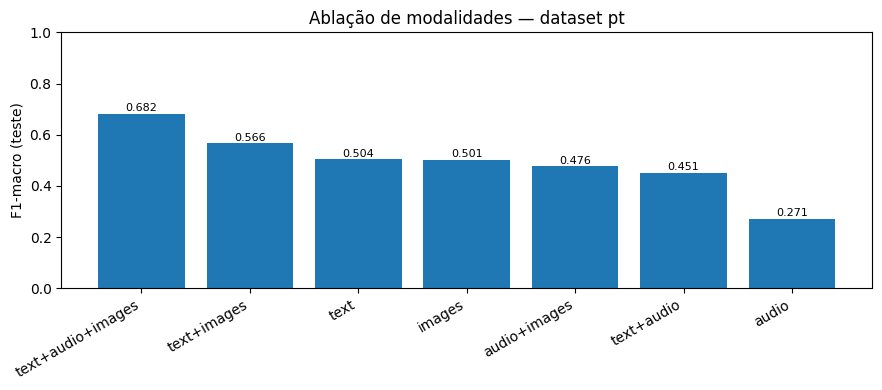

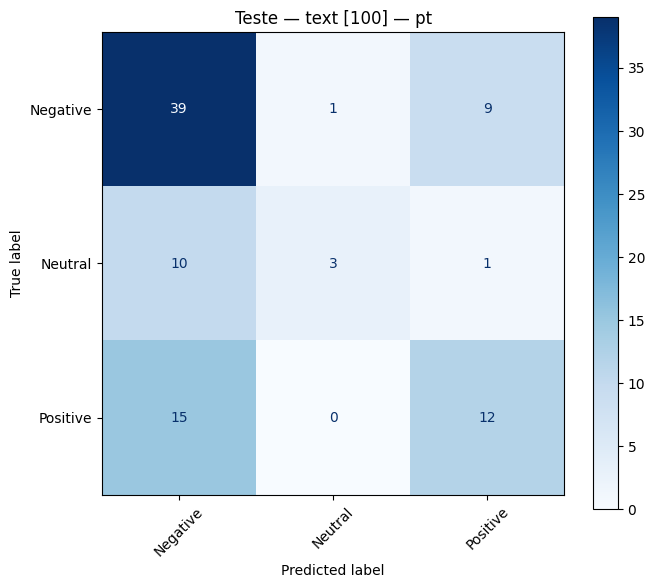

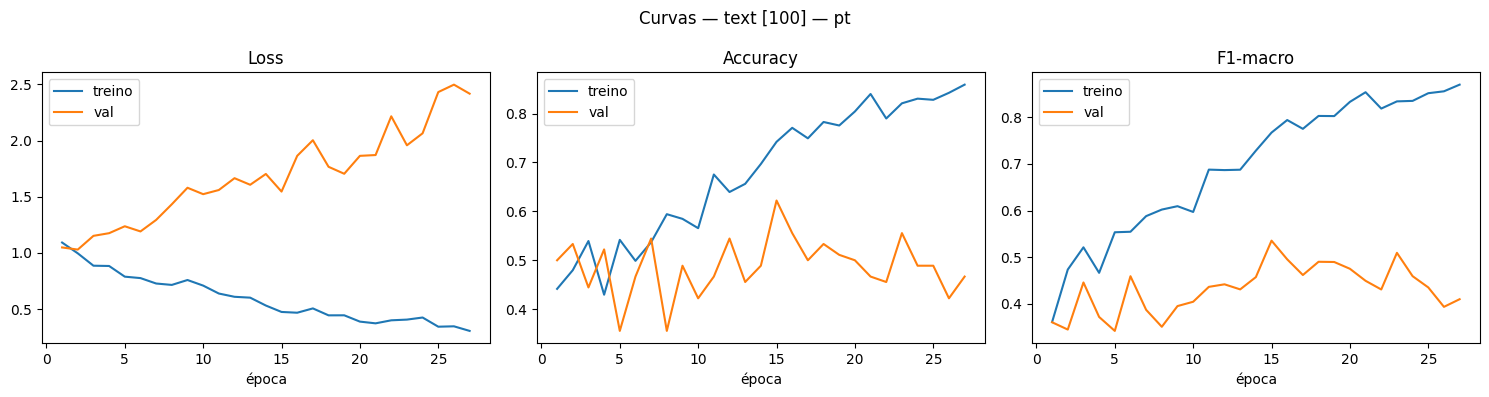

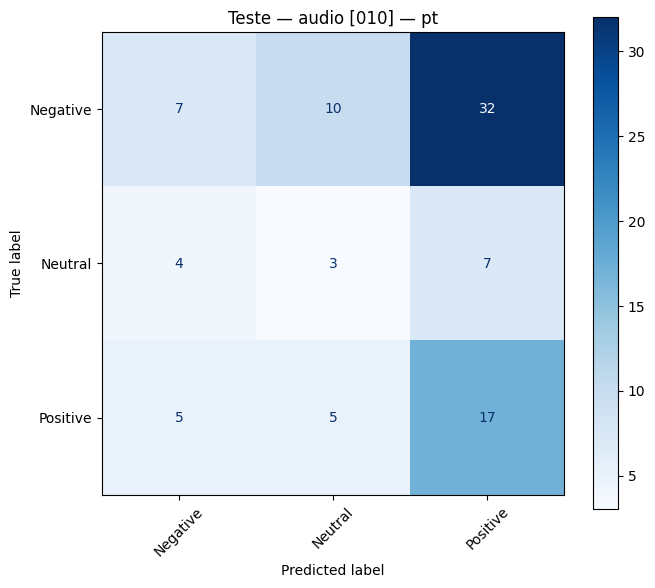

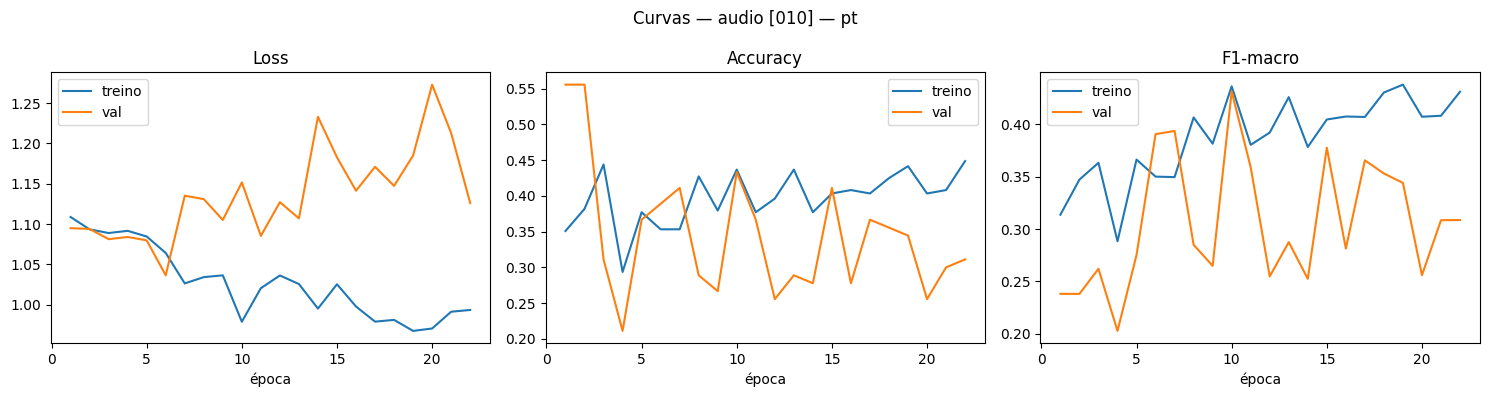

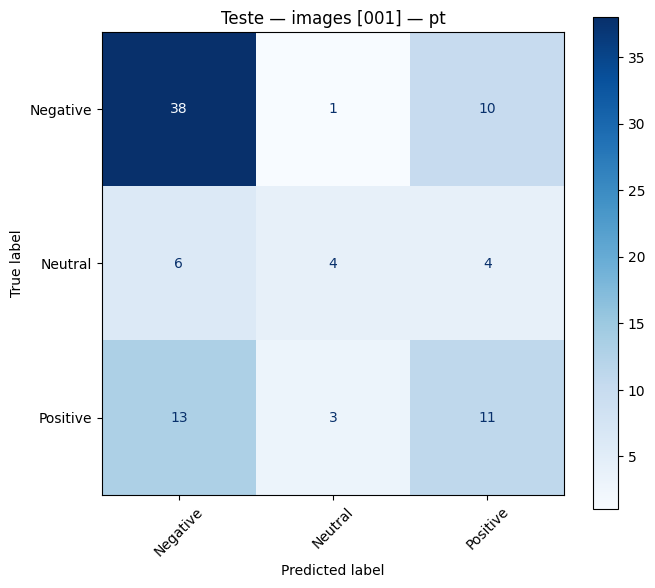

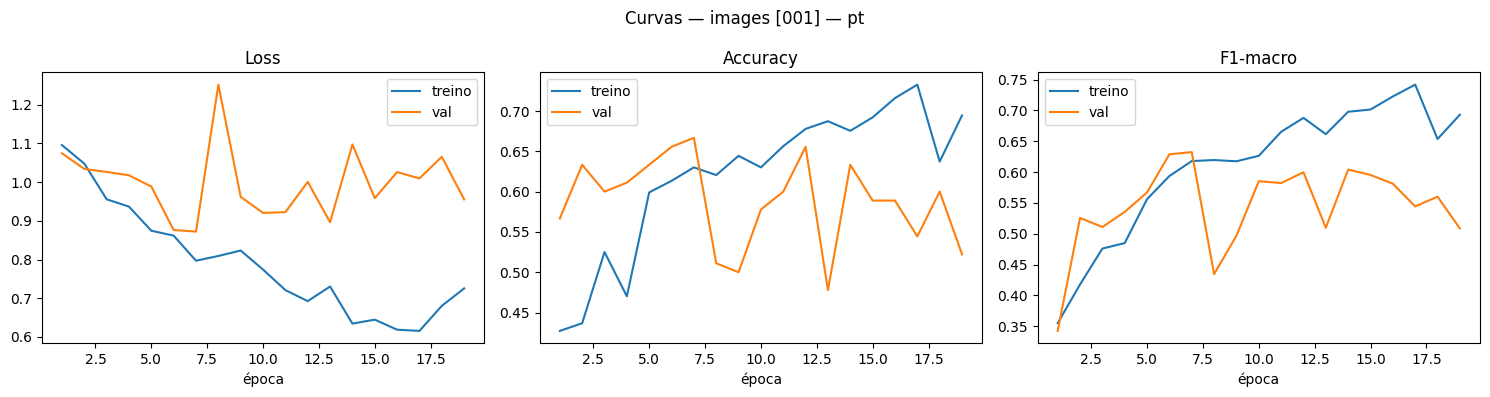

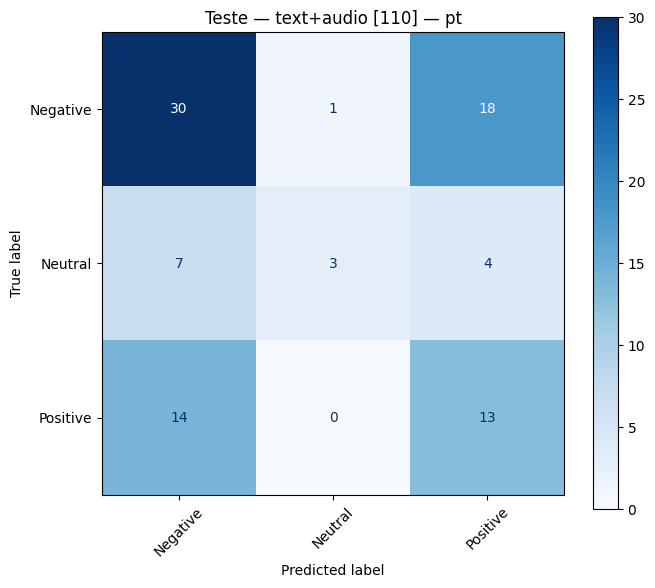

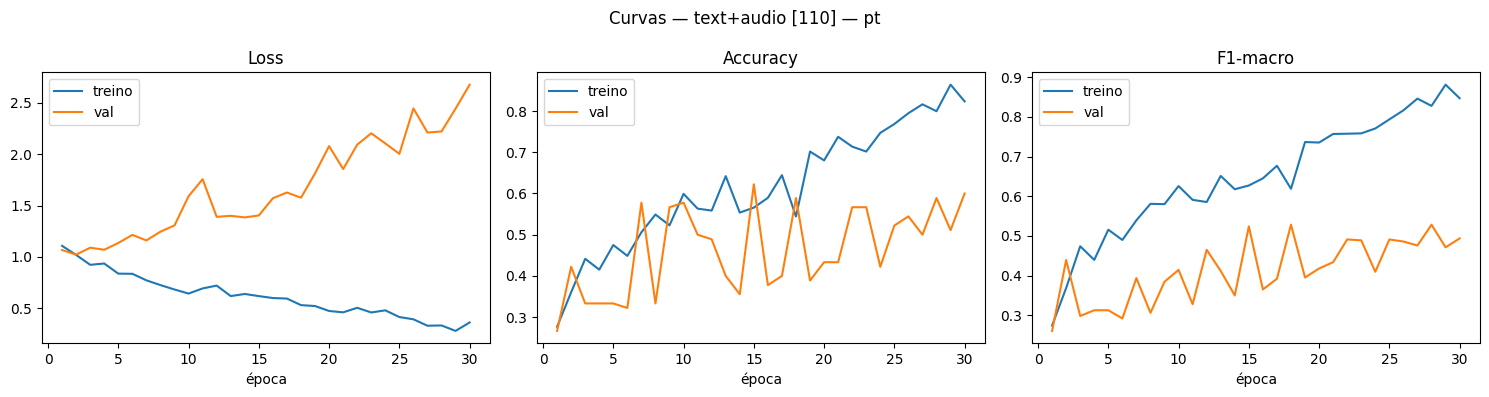

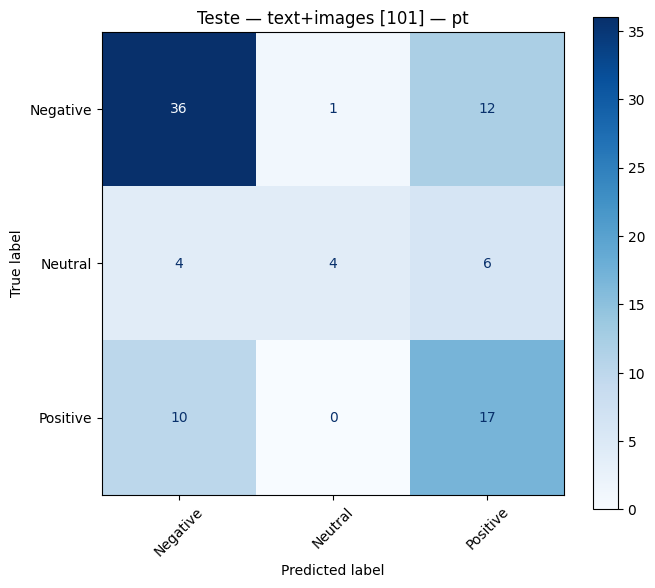

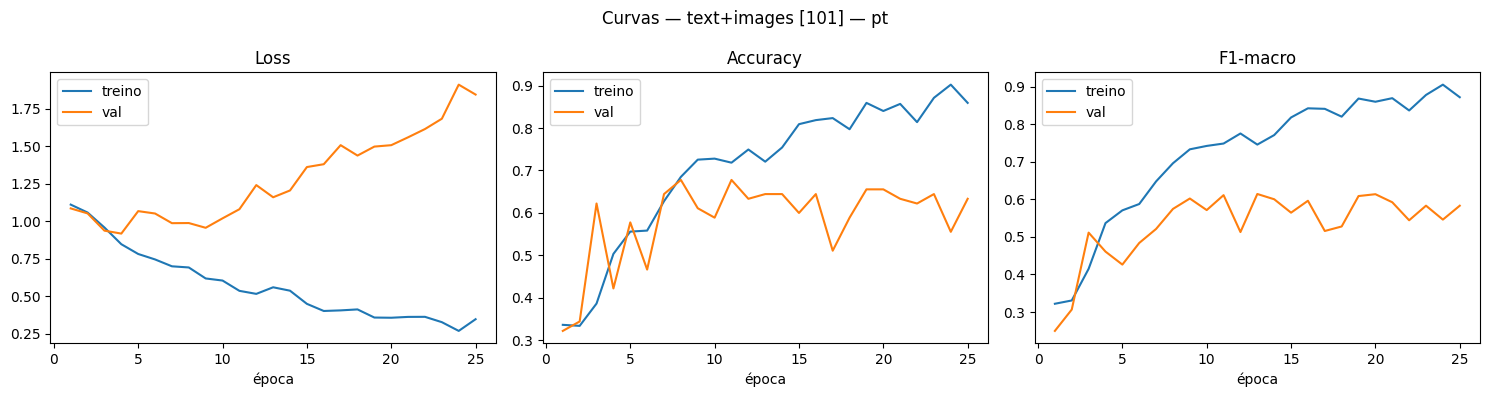

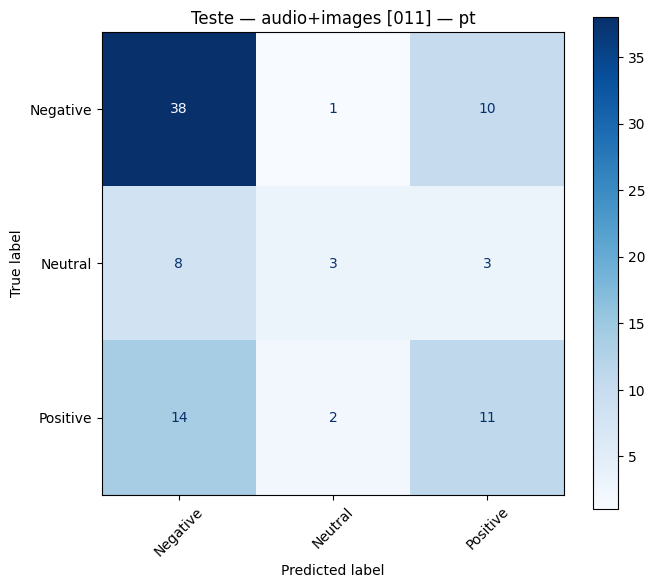

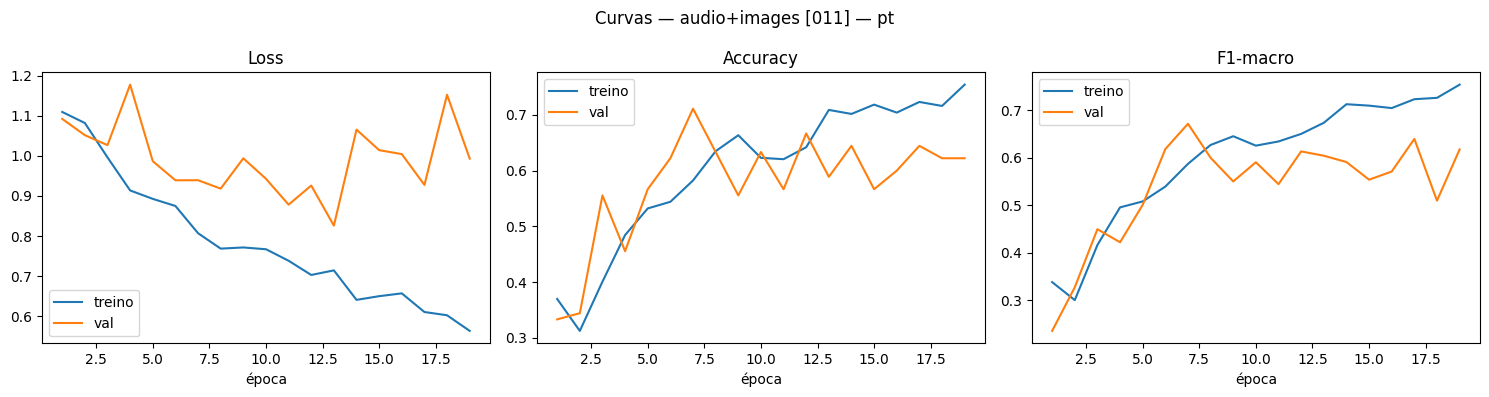

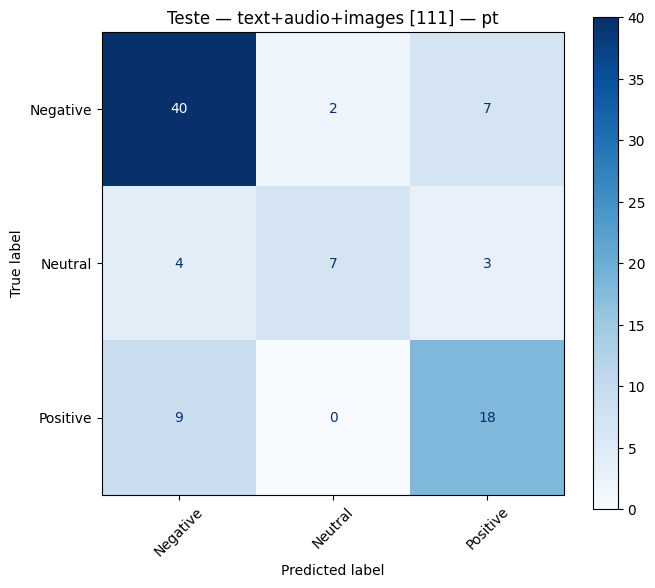

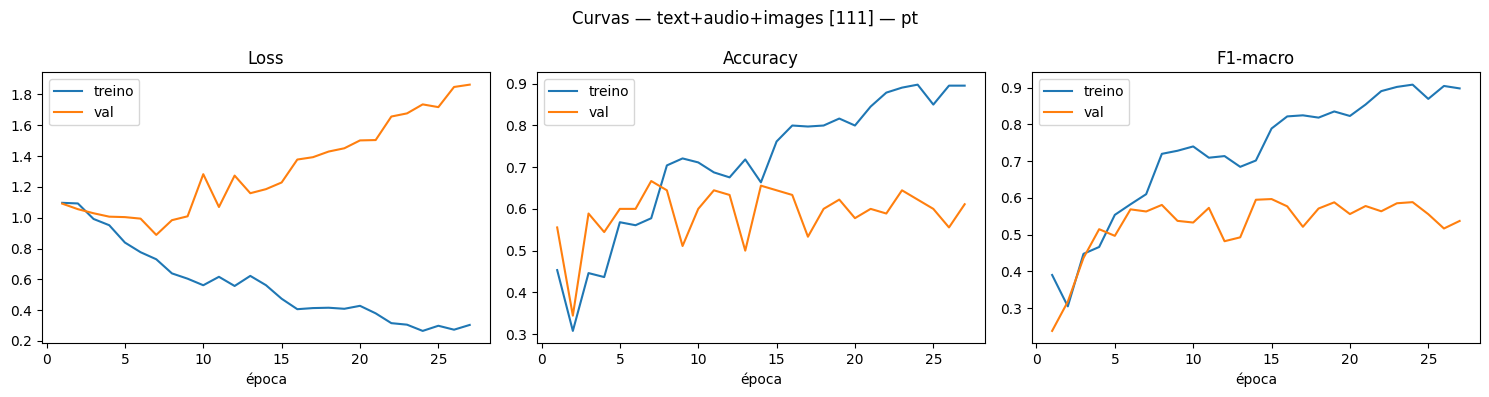

In [98]:
# Gráfico de barras comparando as combinações (quando há mais de uma)
if len(results_table) > 1:
    fig, ax = plt.subplots(figsize=(9, 4))
    xs = range(len(results_table))
    ax.bar(xs, results_table["test_f1_macro"])
    ax.set_xticks(list(xs))
    ax.set_xticklabels(results_table["modalities"], rotation=30, ha="right")
    ax.set_ylabel("F1-macro (teste)"); ax.set_ylim(0, 1)
    ax.set_title(f"Ablação de modalidades — dataset {dataset}")
    for i, v in enumerate(results_table["test_f1_macro"]):
        ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=8)
    plt.tight_layout()
    plt.show()

# Matriz de confusão e curvas de treino por combinação
for mask, d in detailed.items():
    plot_confusion(d["y_true"], d["y_pred"], LABEL_NAMES, f"Teste — {d['name']} [{mask}] — {dataset}")
    plot_history(d["history"], f"Curvas — {d['name']} [{mask}] — {dataset}")